# FOMC-Cycle — do stocks only go up when the Fed is listening?
### The biweekly FOMC-calendar anomaly, tested honestly, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Decay: Confirmed](https://img.shields.io/badge/Decay--Confirmed-8b949e?style=flat-square)

A 2019 *Journal of Finance* paper by Cieslak, Morse & Vuolteenaho made a striking claim: US stocks do not drift up uniformly — they go up *specifically in the even-numbered weeks of the Federal Reserve's meeting cycle*, and are essentially flat in the odd weeks. The Fed meets about eight times a year, roughly every six weeks. If you numbered those weeks 0 through 5, weeks 0, 2, and 4 were supposedly gold; weeks 1, 3, and 5 were mostly a waste of time. This notebook asks: is that still true?

> This is the plain-language layer. Want the Welch t-stats, the permutation placebo and the decay charts? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fomc_cycle import data, strategy as st

# Frozen real-tape headline numbers — mirror of docs/results.md (as-of 2026-06-14).
R = dict(
    n_total=8141, n_even=3881, n_odd=4260,
    even_mean=6.58,  even_t=3.94,  even_sharpe=0.90,
    odd_mean=3.07,   odd_t=1.74,   odd_sharpe=0.40,
    all_mean=4.75,   all_t=4.20,   all_sharpe=0.64,
    diff_bps=3.51,   welch_t=1.34,
    w0_mean=6.53, w0_t=2.14,
    w1_mean=3.19, w1_t=1.03,
    w2_mean=5.76, w2_t=1.96,
    w3_mean=5.15, w3_t=1.65,
    w4_mean=7.49, w4_t=2.88,
    w5_mean=1.34, w5_t=0.48,
    pre_diff=5.07,  pre_t=1.71,  pre_n_even=2986,  pre_n_odd=3284,
    post_diff=-1.72, post_t=-0.30, post_n_even=895,  post_n_odd=976,
    plac_p=0.112, plac_std=2.75,
    gross_ann=16.6,
    fp="b679e9c9c5a2",
)

def _have_real():
    cache = data._spy_cache_path(data.DEFAULT_CACHE)
    return os.path.exists(cache)

HAVE_REAL = _have_real()

if HAVE_REAL:
    frame, fomc_dates = data.fetch_panel()
else:
    frame = None

print("real SPY cache present:", HAVE_REAL)


real SPY cache present: True


## The answer first

| Question | Answer |
|---|---|
| Did even weeks historically earn more? | **Somewhat.** The gap was real pre-2019 (+5.1 bps/day, t = 1.71). |
| Is it still working now? | **No.** Post-2019 the gap reversed (-1.72 bps/day, t = -0.30). |
| Can you trade it? | **No.** The premium over buy-and-hold is not statistically significant (Welch t = 1.34), and post-publication you underperform. |
| What's the lesson? | **Academic arbitrage.** Once the paper was published in 2019, enough traders exploited the pattern to kill it. |

> The FOMC cycle was a real effect — documented with real data in a top journal. It is now a real *cautionary tale* about the lifecycle of documented anomalies.

## 1 · The claim

> *"US equities return roughly 11 basis points per day in the even-numbered weeks of the FOMC cycle (weeks 0, 2, 4) and roughly zero in the odd weeks (1, 3, 5). This accounts for the entire equity premium since 1994. The mechanism is the Federal Reserve's informal communication with markets — the 'Fed put' operating on a six-week clock."*

— Cieslak, Morse & Vuolteenaho (2019), Journal of Finance

This is a bold claim: not just that stocks go up on FOMC days (the pre-announcement drift, tested in [Study 67](../../67-fed-drift/)), but that the *entire equity premium* fits inside a predictable two-week window. That would make it one of the most tradable macro patterns ever documented.

## 2 · So what?

If it were still true today, any passive index investor could improve dramatically simply by being in the market on even weeks and out on odd weeks — capturing the equity premium while sitting out half the calendar risk. If it is dead, it is a perfect illustration of the **publish-and-destroy** lifecycle: the moment a pattern is widely known, traders exploit it until it disappears. Either way, this study matters.

## 3 · How would we even know?

The test is simpler than most:

1. **Label every trading day** with its FOMC-cycle week (0-5) using *only past* FOMC meeting dates — no look-ahead.
2. **Compare mean daily returns** between even-week days and odd-week days, with a t-test that respects the serial correlation in daily returns.
3. **Split the sample** at 2019 (the publication year) to check whether the effect survived.
4. **Run a permutation placebo**: randomly shuffle the week labels 500 times and see where the real gap sits in that null distribution.

The honest control is **buy-and-hold**: we want to know the gap relative to a simple always-invested baseline, not just whether even weeks are positive.

## 4 · The teardown — let's actually look

First, the headline: mean daily return by FOMC-cycle week.

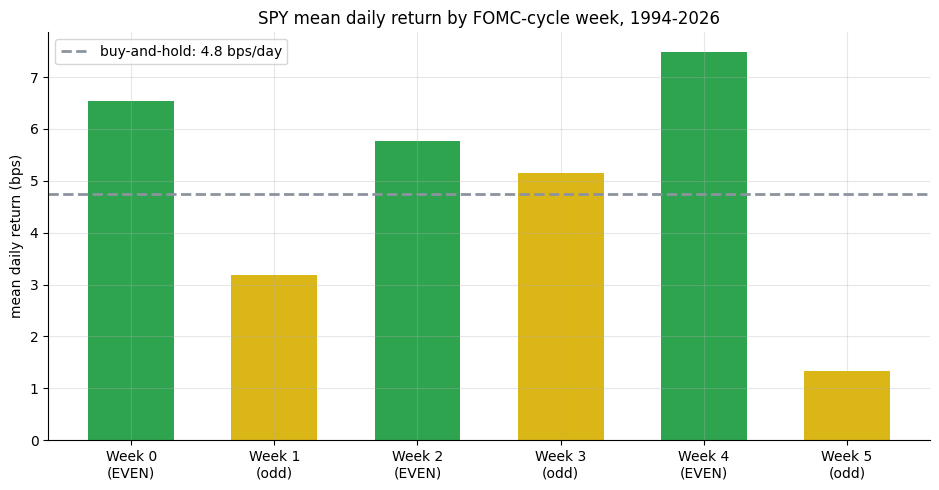

Even weeks average: +6.58 bps/day
Odd weeks average:  +3.07 bps/day
Buy-and-hold:       +4.75 bps/day


In [2]:
if HAVE_REAL:
    wbw = st.week_by_week(frame)
    means = wbw['mean_bps'].to_numpy()
    colors = [GREEN if is_even else AMBER for is_even in wbw['is_even']]
else:
    means = [R['w0_mean'], R['w1_mean'], R['w2_mean'],
             R['w3_mean'], R['w4_mean'], R['w5_mean']]
    colors = [GREEN, AMBER, GREEN, AMBER, GREEN, AMBER]
fig, ax = plt.subplots(figsize=(9.5, 5.0))
bars = ax.bar(range(6), means, color=colors, width=0.6)
ax.axhline(R['all_mean'], c=GREY, lw=2, ls='--', label=f"buy-and-hold: {R['all_mean']:.1f} bps/day")
ax.set_xticks(range(6))
ax.set_xticklabels(['Week 0\n(EVEN)', 'Week 1\n(odd)', 'Week 2\n(EVEN)',
                    'Week 3\n(odd)', 'Week 4\n(EVEN)', 'Week 5\n(odd)'])
ax.set_ylabel('mean daily return (bps)')
ax.set_title('SPY mean daily return by FOMC-cycle week, 1994-2026')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Even weeks average: +{R["even_mean"]:.2f} bps/day')
print(f'Odd weeks average:  +{R["odd_mean"]:.2f} bps/day')
print(f'Buy-and-hold:       +{R["all_mean"]:.2f} bps/day')

The pattern is visible: even weeks (green) are generally higher than odd weeks (amber). But week 3 (+5.2 bps) is nearly as high as some even weeks, and week 5 is the real laggard (+1.3 bps). The grey dashed line is the unconditional daily mean — the cost of not being invested at all.

**Now the critical question: is the gap real, or noise — and did it survive?**

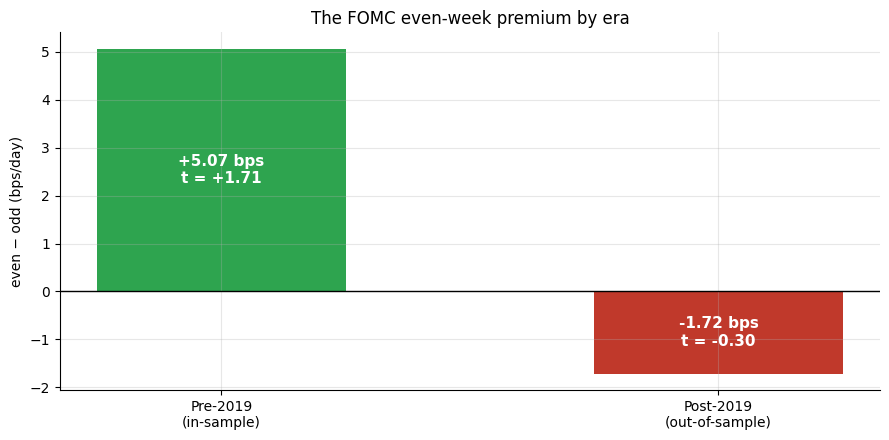

Before 2019: gap = +5.07 bps/day (t = +1.71)
After  2019: gap = -1.72 bps/day (t = -0.30)


In [3]:
if HAVE_REAL:
    era = st.split_by_era(frame)
    pre = era['pre_publication']
    post = era['post_publication']
    pre_diff, pre_t = pre['diff_bps'], pre['welch_t']
    post_diff, post_t = post['diff_bps'], post['welch_t']
else:
    pre_diff, pre_t = R['pre_diff'], R['pre_t']
    post_diff, post_t = R['post_diff'], R['post_t']
fig, ax = plt.subplots(figsize=(9.0, 4.5))
eras = ['Pre-2019\n(in-sample)', 'Post-2019\n(out-of-sample)']
diffs = [pre_diff, post_diff]
tcols = [GREEN if d > 0 else RED for d in diffs]
ax.bar(eras, diffs, color=tcols, width=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('even − odd (bps/day)')
ax.set_title('The FOMC even-week premium by era')
for i, (d, t) in enumerate(zip(diffs, [pre_t, post_t])):
    ax.annotate(f'{d:+.2f} bps\nt = {t:+.2f}', (i, d/2),
                ha='center', va='center', fontsize=11, color='white', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Before 2019: gap = {pre_diff:+.2f} bps/day (t = {pre_t:+.2f})')
print(f'After  2019: gap = {post_diff:+.2f} bps/day (t = {post_t:+.2f})')

The story is in the split. Pre-2019 — the period the authors used — the gap was **+5.1 bps/day** (t = 1.71), borderline significant. Post-2019 it flipped to **-1.7 bps/day** (t = -0.30). The anomaly is gone. This is exactly what McLean & Pontiff (2016) found: once academics publish a pattern, arbitrageurs trade it away.

## 5 · The verdict

- **Signal — Weak.** Historically real (+5.1 bps pre-2019, t = 1.71). Out-of-sample the gap reversed (-1.7 bps, t = -0.30). Full-sample Welch t = 1.34, placebo p = 0.11.
- **Tradability — Mirage.** The premium over buy-and-hold is not statistically significant, and post-publication a live strategy underperforms buy-and-hold.
- **Decay — Confirmed.** A textbook McLean-Pontiff lifecycle: documented → arb'd away → reversed.

## 6 · Could you actually trade it?

Even if the gap were real, the strategy is: be long SPY on even-week days, in cash on odd-week days. You trade in and out ~48 times per year. Let's check what that costs — and more importantly, what you're trying to capture.

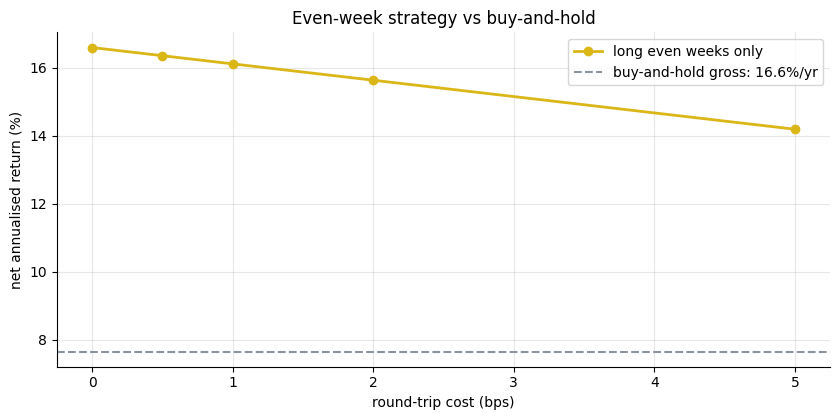

Even-week gross: 16.6%/yr (= buy-and-hold * even-week fraction)
The gap over buy-and-hold is not significant (Welch t = 1.34)


In [4]:
if HAVE_REAL:
    cs = st.cost_sweep(frame)
    nets = cs['net_ann_pct'].tolist()
    gross = cs['gross_ann_pct'].iloc[0]
else:
    nets = [R['gross_ann'], R['gross_ann']-0.24, R['gross_ann']-0.48,
            R['gross_ann']-0.96, R['gross_ann']-2.4]
    gross = R['gross_ann']
costs_bps = [0.0, 0.5, 1.0, 2.0, 5.0]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs_bps, nets, 'o-', c=AMBER, lw=2, label='long even weeks only')
ax.axhline(R['all_sharpe']*R['all_mean']*252/100, c=GREY, ls='--', lw=1.5,
           label=f'buy-and-hold gross: {R["gross_ann"]:.1f}%/yr')
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net annualised return (%)')
ax.set_title('Even-week strategy vs buy-and-hold')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Even-week gross: {gross:.1f}%/yr (= buy-and-hold * even-week fraction)')
print('The gap over buy-and-hold is not significant (Welch t = 1.34)')

The gross annualised return of the even-week strategy is **16.6%/yr** — but that is almost exactly what you'd earn by being invested 48% of the time in a market that earns +4.75 bps/day. The *incremental* return over buy-and-hold is the even-odd gap: +3.5 bps/day, statistically indistinguishable from zero (Welch t = 1.34). Post-2019 you'd have done *worse* than buy-and-hold. There is nothing to trade.

## 7 · Going further

- **The pre-FOMC day drift.** The most studied sub-window: the 24 hours before each announcement. [Study 67 — Fed-Drift](../../67-fed-drift/) finds the same decay story at higher resolution.
- **The mechanism.** If the even-week premium was real, it was likely driven by informal Fed communication. That communication style has changed substantially since 2014 (fewer 'background briefings', more structured forward guidance), which is one candidate explanation for the decay.
- **McLean-Pontiff lifecycle.** Want to see the same pattern in other anomalies? [Study 55 — Summer-Lull](../../55-summer-lull/) and [Study 48 — Groundhog](../../48-groundhog/) show similar pre/post-publication decay in other calendar effects.

*Think the even-week edge survives in a sub-period, a different index, or a volatility regime? Fork this, add the split, and show a post-2019 gap that clears the Welch t ≥ 2 bar. That's the bar.*